In [53]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from models import CondSM
import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 12,          # base font (affects cbar label unless overridden)
    "xtick.labelsize": 14,    # affects horizontal colorbar ticks
    "ytick.labelsize": 14,    # affects vertical colorbar ticks
    # Optional extras you may want:
    "axes.titlesize": 12,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "font.family": "serif",
    "mathtext.fontset": "cm",
})
# ----------------------------
# Device + model load
# ----------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_types = ['uni_1e7', 'data_vMB_ring_1e7', 'grad_towards_1e7', 'grad_away_1e7']
data_type = 'grad_away_1e7'
state_dict = torch.load(
    f'/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/final_datasets/{data_type}/'
    f'sm_{data_type}_baseline_0_epochs=1000_dp=0.1_bn=True_hd=90_ls=5_noise=True.pth',
    weights_only=False,
    map_location=device
)

model = CondSM(state_dict['layer_dims'], state_dict['dropout'], state_dict['batch_norm'])
model.load_state_dict(state_dict['model_state_dict'])
model = model.to(device).eval()

input_index = 3
print("Model loaded")

# ----------------------------
# Target function
# ----------------------------
func_type = 'Cosine'

if func_type == 'ReLU':
    def target_function(x): return nn.ReLU()(x)
elif func_type == 'Sigmoid':
    def target_function(x): return nn.Sigmoid()(4 * x)
elif func_type == 'Parabola':
    def target_function(x): return x ** 2
elif func_type == 'Cubic':
    def target_function(x): return x ** 3
elif func_type == 'Sine':
    def target_function(x): return torch.sin(3 * x)
elif func_type == 'Cosine':
    def target_function(x): return torch.cos(3 * x)
elif func_type == 'Linear':
    def target_function(x): return x
elif func_type == 'Gaussian':
    def target_function(x): return torch.exp(-x**2 / 2)
else:
    raise ValueError(f"Unknown func_type: {func_type}")

# ----------------------------
# Affine-aligned loss (gain+offset fit)
# ----------------------------
def affine_aligned_mse(y, t, eps=1e-12, enforce_positive_gain=False):
    """
    Fits a,b per sample to minimize ||a*y + b - t||^2 and returns the MSE residual.

    y: [B, P] or [P]
    t: [P] or [B, P] (broadcastable)
    returns:
      mse: [B] (or scalar if B=1)
      a:   [B]
      b:   [B]
    """
    if y.ndim == 1:
        y = y.unsqueeze(0)  # [1, P]
    if t.ndim == 1:
        t = t.unsqueeze(0).expand_as(y)

    y_mean = y.mean(dim=1, keepdim=True)
    t_mean = t.mean(dim=1, keepdim=True)

    y0 = y - y_mean
    t0 = t - t_mean

    var_y = (y0 * y0).mean(dim=1, keepdim=True)          # [B,1]
    cov_yt = (y0 * t0).mean(dim=1, keepdim=True)         # [B,1]

    a = cov_yt / (var_y + eps)
    if enforce_positive_gain:
        a = torch.clamp(a, min=0.0)

    b = t_mean - a * y_mean

    y_fit = a * y + b
    mse = ((y_fit - t) ** 2).mean(dim=1)                 # [B]
    return mse, a.squeeze(1), b.squeeze(1)

Model loaded


control_indices: [0, 1, 2, 4, 5, 6]
min_index: 908041
min_score (affine-aligned MSE): 0.15223294496536255
theta_best: [0.23254473507404327, 0.5455320477485657, 1.1577068567276, -0.1784190684556961, -1.457958459854126, -0.388016015291214]
best gain a*: 0.9446585178375244
best offset b*: 3.7745437622070312
Done
Saved text with columns: theta0 theta1 theta2 theta3 theta4 theta5 score_affine_mse


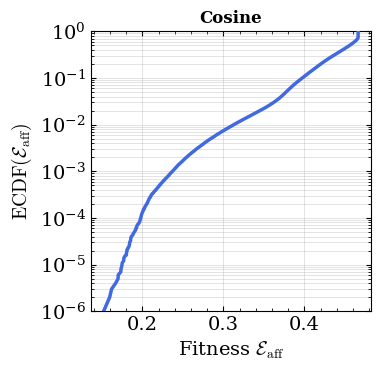

In [54]:
# ----------------------------
# Setup sweep + sampling
# ----------------------------
seed = 42
torch.manual_seed(seed)

num_curve_points = 50
num_voltages = 7
control_indices = [c for c in range(num_voltages) if c != input_index]
print("control_indices:", control_indices)

v_min, v_max = -1.5, 1.5
curve_range = torch.linspace(v_min, v_max, num_curve_points, device=device)           # [P]
target_input_range = torch.linspace(v_min, v_max, num_curve_points, device=device).unsqueeze(1)  # [P,1]
target = target_function(target_input_range).squeeze(-1)                              # [P]

num_samples = 1_000_000
c_v_min, c_v_max = -1.5, 1.5

# sample control voltages
thetas = torch.rand((num_samples, 6), device=device, dtype=torch.float32) * (c_v_max - c_v_min) + c_v_min

# L2-ball projection
max_l2 = 2.0
l2 = thetas.norm(dim=1)
scale = torch.clamp(max_l2 / (l2 + 1e-12), max=1.0)
thetas = thetas * scale.unsqueeze(1)

# prebuild base input [P, V]
base = torch.zeros(num_curve_points, num_voltages, device=device, dtype=torch.float32)
base[:, input_index] = curve_range

control_indices_t = torch.tensor(control_indices, device=device, dtype=torch.long)

# ----------------------------
# Batched evaluation (vectorized scoring)
# ----------------------------
batch_size = 4 * 4096  # tune based on VRAM
scores = torch.empty(num_samples, device=device, dtype=torch.float32)

best_a = None
best_b = None

with torch.inference_mode():
    for start in range(0, num_samples, batch_size):
        end = min(start + batch_size, num_samples)
        B = end - start

        # [B, P, V]
        x = base.unsqueeze(0).expand(B, -1, -1).clone()

        # fill controls
        controls = thetas[start:end].unsqueeze(1).expand(-1, num_curve_points, -1)  # [B,P,6]
        x.index_copy_(2, control_indices_t, controls)

        # flatten to [B*P, V]
        x2d = x.reshape(-1, num_voltages)

        # model output
        y = model(x2d)

        # reshape back to [B, P]
        if y.ndim == 2 and y.shape[1] == 1:
            y = y.squeeze(1)  # [B*P]
        y = y.reshape(B, num_curve_points)  # [B,P]

        # affine-aligned MSE per sample (gain+offset fit)
        loss_b, a_b, b_b = affine_aligned_mse(y, target, enforce_positive_gain=True)

        scores[start:end] = loss_b

# ----------------------------
# Find best sample
# ----------------------------
scores_cpu = scores.detach().cpu().numpy()
min_index = int(np.argmin(scores_cpu))
min_score = float(scores_cpu[min_index])

theta_best = thetas[min_index].detach().cpu().numpy().tolist()

print("min_index:", min_index)
print("min_score (affine-aligned MSE):", min_score)
print("theta_best:", theta_best)

# recompute best a,b for the best theta (optional, for reporting)
with torch.inference_mode():
    x_best = base.clone()
    x_best[:, control_indices_t] = torch.tensor(theta_best, device=device).unsqueeze(0).expand(num_curve_points, -1)
    y_best = model(x_best).detach()
    if y_best.ndim == 2 and y_best.shape[1] == 1:
        y_best = y_best.squeeze(1)
    y_best = y_best.reshape(1, num_curve_points)  # [1,P]
    loss1, a1, b1 = affine_aligned_mse(y_best, target, enforce_positive_gain=True)
    print("best gain a*:", float(a1.item()))
    print("best offset b*:", float(b1.item()))

print("Done")

# ----------------------------
# Save top-K thetas as text/CSV
# ----------------------------
K = 100

top_vals, top_idx = torch.topk(scores, k=K, largest=False)
top_thetas = thetas[top_idx]

top_vals_cpu = top_vals.detach().cpu().numpy()[:, None]   # (K,1)
top_thetas_cpu = top_thetas.detach().cpu().numpy()        # (K,6)

out = np.concatenate([top_thetas_cpu, top_vals_cpu], axis=1)  # (K,7)

header = "theta0 theta1 theta2 theta3 theta4 theta5 score_affine_mse"
np.savetxt(
    f'/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/1d_funcs_random_mse/'
    f'topK_random_affine_data_type={data_type}_func={func_type}_cmin={c_v_min}_cmax={c_v_max}_seed={seed}_'
    f'maxl2={max_l2}_input_idx={input_index}_K={K}.txt',
    out,
    header=header,
)

print("Saved text with columns:", header)

# ----------------------------
# ECDF plot (same style as yours)
# ----------------------------

s = scores.detach().cpu().numpy().astype(float)
s = s[np.isfinite(s)]
s_sorted = np.sort(s)
n = len(s_sorted)
ecdf = np.arange(1, n + 1) / n

fig, ax = plt.subplots(figsize=(4, 4))
#ax.set_position([0.18, 0.12, 0.76, 0.83])
ax.set_position([0.24, 0.12, 0.70, 0.83])
ax.minorticks_on()
ax.tick_params(top=True, right=True, which='both')
ax.tick_params(which='both', direction='in')

ax.set_ylabel(r'$\mathrm{ECDF}(\mathcal{E}_{\mathrm{aff}})$')
ax.set_ylim(1 / n, 1)
ax.set_yscale('log')
ax.plot(s_sorted, ecdf, lw=2.5, zorder=6, c='royalblue')

ax.grid(lw=0.5, alpha=0.5, which='major')
ax.grid(lw=0.5, alpha=0.5, which='minor', axis='y')

ax.set_xlabel(r'Fitness $\mathcal{E}_{\mathrm{aff}}$')
ax.set_box_aspect(1)
ax.set_title(f'{func_type}', fontdict={'weight': 'bold'})

plt.show()

# ----------------------------
# Optional saving (uncomment + adjust paths)
# ----------------------------

fig.savefig(
    f'random_mse_ecdf_affine_data_type={data_type}_func={func_type}_'
    f'cmin={c_v_min}_cmax={c_v_max}_seed={seed}_maxl2={max_l2}_input_idx={input_index}.pdf'
)

np.savetxt(
    f'/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/1d_funcs_random_mse/'
    f'random_affine_data_type={data_type}_func={func_type}_cmin={c_v_min}_cmax={c_v_max}_seed={seed}_'
    f'maxl2={max_l2}_input_idx={input_index}.txt',
    theta_best
)

np.savetxt(
    f'/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/1d_funcs_random_mse/'
    f'scores_random_affine_data_type={data_type}_func={func_type}_cmin={c_v_min}_cmax={c_v_max}_seed={seed}_'
    f'maxl2={max_l2}_input_idx={input_index}.txt',
    scores_cpu
)

## Sensitivity


E(theta*): 0.0002711233391892165


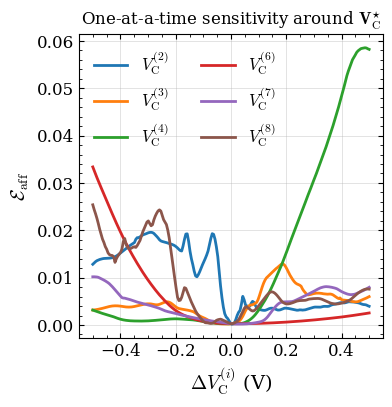

Local sensitivities |dE/dθ| (ranked):
  θ0: 2.1158e-02
  θ1: 1.0495e-02
  θ4: 4.3543e-03
  θ2: 6.5824e-04
  θ5: 3.8037e-04
  θ3: 3.1769e-04


In [35]:
# ---- helper: score a batch of thetas (Nx6) ----
@torch.inference_mode()
def score_thetas(thetas_batch: torch.Tensor) -> torch.Tensor:
    """
    thetas_batch: [N,6] on device
    returns: scores [N] (affine-aligned MSE)
    """
    N = thetas_batch.shape[0]
    x = base.unsqueeze(0).expand(N, -1, -1).clone()  # [N,P,V]
    controls = thetas_batch.unsqueeze(1).expand(-1, num_curve_points, -1)  # [N,P,6]
    x.index_copy_(2, control_indices_t, controls)
    x2d = x.reshape(-1, num_voltages)
    y = model(x2d)
    if y.ndim == 2 and y.shape[1] == 1:
        y = y.squeeze(1)
    y = y.reshape(N, num_curve_points)
    loss, _, _ = affine_aligned_mse(y, target, enforce_positive_gain=True)
    return loss

theta_star = torch.tensor(theta_best, device=device, dtype=torch.float32)  # [6]
E_star = float(score_thetas(theta_star.unsqueeze(0)).item())
print("E(theta*):", E_star)

# ---- OAT sweep settings ----
K = 200                     # points per parameter sweep
delta = 0.5              # +/- volts around theta*
sweep = torch.linspace(-delta, delta, K, device=device)

sens = []
curves = []  # store for plotting

for i in range(6):
    thetas_i = theta_star.repeat(K, 1)
    thetas_i[:, i] = theta_star[i] + sweep

    # enforce your L2-ball projection (same as before)
    l2 = thetas_i.norm(dim=1)
    scale = torch.clamp(max_l2 / (l2 + 1e-12), max=1.0)
    thetas_i = thetas_i * scale.unsqueeze(1)

    E_i = score_thetas(thetas_i)  # [K]
    curves.append(E_i.detach().cpu().numpy())

    # simple local sensitivity: slope estimate around 0
    # (central difference using neighbors of index mid)
    mid = K // 2
    dE = float(E_i[mid+1] - E_i[mid-1])
    dtheta = float(sweep[mid+1] - sweep[mid-1])
    sens.append(abs(dE / dtheta))

# ---- plot OAT curves ----
fig, ax = plt.subplots(figsize=(4,4))
ax.set_box_aspect(1)
ax.set_position([0.18, 0.12, 0.76, 0.83])
ax.minorticks_on()
ax.tick_params(top=True, right=True, which='both')
ax.tick_params(direction='in', which='both')

control_indices = [0, 1, 2, 4, 5, 6]
for i, c_idx in enumerate(control_indices):
    ax.plot(sweep.detach().cpu().numpy(), curves[i], lw=2, label=rf"$V^{{({c_idx+2})}}_{{\mathrm{{C}}}}$")
#ax.axvline(0, lw=1)
ax.set_xlabel(r"$\Delta V_{{\mathrm{{C}}}}^{(i)}$ (V)")
ax.set_ylabel(r"$\mathcal{E}_{\mathrm{aff}}$")
ax.set_title(r"One-at-a-time sensitivity around $\mathbf{V}_{\mathrm{C}}^{\star}$")
ax.legend(ncol=2, frameon=False)
ax.grid(alpha=0.5, lw=0.5)
plt.show()

# ---- print ranked local sensitivities ----
order = np.argsort(-np.array(sens))
print("Local sensitivities |dE/dθ| (ranked):")
for k in order:
    print(f"  θ{k}: {sens[k]:.4e}")